# Particle tracking

**A Soliloquy Beneath the Water Table**

To drape or to drop, that’s the question—
Whether ’tis nobler in the porous mind
To suffer the gradients of outrageous flux,
Or to take arms against a sea of heads
And, by opposing, end them.
To flow, to seep—
No more—and by a seep to say we end
The slings and arrows of stochastic rain,
The thousand natural shocks that aquifers bear—
’Tis a consummation devoutly sensed.
To flow, to seep—
To seep, perchance to plume—ay, there’s the rub:
For in that plume of dissolved mystery
What heterogeneity may come,
When we have shuffled off this Darcy coil,
Must give us pause.
There’s the respect
That makes calamity of long retardation:
For who would bear the whips and scorns of time—
Pumping stress, inverse woes, parameter shame—
The pangs of unmodeled boundaries, the law’s delay,
The insolence of numerical dispersion,
And spurns that patient merit of the grid—
When he himself might his quietus make
With but a steady state?
Who would burdens bear,
To grunt and sweat beneath a transient load,
But that the dread of something after flow—
The undiscovered zone from which no tracer
Returns unbiased—puzzles the will,
And makes us rather bear those ills we have
Than drift to others that we know not of?
Thus conscience does make cowards of us all,
And thus the native hue of resolution
Is sicklied o’er with the pale cast of doubt,
And enterprises of great pitch and moment—
Conceptual models, grand and elegant—
With this regard their currents turn awry
And lose the name of action.
Soft you now,
Fair aquifer—remember me in recharge.

This example demonstrates forward particle tracking with a transient flow system.
The model represents a seepage scenario in which more permeable layers at higher
elevation start out dry, and gradually wet over the course of the simulation, as
the flow system receives water from boundary conditions. Particles are released
into the top layer, which starts out dry.

We will first run the flow model, show how to accommodate particles released above the water table, and show that PRT and MP7 produce equivalent particle tracking results. Then
we will modify the flow model to use the Newton  formulation, such that dry cells
remain active. PRT provides more flexible behavior in this circumstance than MP7.
We will demonstrate how to control particle behavior in dry conditions with PRT.

First, define units.

In [75]:
time_unit = "days"
length_unit = "meters"

Set up a time discretization with 3 stress periods: one steady-state, one
transient, and a final steady-state. The injection well will be active only in the
second period.

In [76]:
nper = 3
tdis_pd = [
    (1, 1, 1.0),
    (300, 30, 1.1),
    (1000, 1, 1.0),
]

Set up a grid discretization: three 10m-thick layers below a 1600m top surface.

In [77]:
import numpy as np

nlay, nrow, ncol = 3, 20, 20
Lx, Ly = 100.0, 100.0
delr, delc = Lx / ncol, Ly / nrow
top = 1600.0
thickness = 10.0
bot = np.zeros((nlay, nrow, ncol))
for k in range(nlay):
    bot[k] = top - (k + 1) * thickness

Construct a flow model which will be used by both PRT and MP7.

In [78]:
from pathlib import Path

example_name = "prt-a"
gwf_name = f"{example_name}-gwf"
base_ws = Path("models") / example_name
gwf_ws = base_ws / "gwf"
gwf_ws.mkdir(exist_ok=True, parents=True)

In [79]:
import flopy

gwf_sim = flopy.mf6.MFSimulation(
    sim_name=gwf_name,
    exe_name="mf6",
    version="mf6",
    sim_ws=gwf_ws,
)

In [80]:
tdis = flopy.mf6.ModflowTdis(
    gwf_sim,
    time_units=time_unit,
    nper=nper,
    perioddata=tdis_pd,
)

In [81]:
gwf = flopy.mf6.ModflowGwf(
    gwf_sim,
    modelname=gwf_name,
    # options="NEWTON",  # TODO uncomment after first pass
    save_flows=True,
)

In [82]:
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    length_units=length_unit,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=bot,
)

Initial conditions begin fully saturated; the first steady state stress period
will cause the water table to drop before it begins to rise in the 2nd period.

In [83]:
ic = flopy.mf6.ModflowGwfic(gwf, strt=top)

The model grid's cells are convertible, with greater hydraulic conductivity in
the lateral than the vertical direction.

In [84]:
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=1,
    k=0.5,
    k33=0.1,
    save_specific_discharge=True,
    save_saturation=True,
    save_flows=True,
)

Configure STO convertibility to match NPF and steady-state/transient options to match
the time discretization.

In [85]:
sto = flopy.mf6.ModflowGwfsto(
    gwf,
    iconvert=1,
    ss=0.0001,
    sy=0.1,
    steady_state={0: True, 2: True},
    transient={1: True},
    save_flows=True,
)

Constant-head boundaries establish a mild head gradient from upper-left to lower-right.

In [86]:
chd0_cellid = (1, 0, 0)
chd1_cellid = (1, nrow - 1, ncol - 1)
chd = flopy.mf6.ModflowGwfchd(
    gwf,
    stress_period_data={i: [
        (*chd0_cellid, 1587.0),
        (*chd1_cellid, 1582.0)
    ] for i in range(nper)},
    save_flows=True,
)

An injection well sits in layer 1 near the upper-left quadrant.
Particles are released from layer 0 (the top, initially dry layer)
in the five cells surrounding the well in plan view.

The injection well is active only in the transient period; pumping rate 100 m³/d.

In [87]:
wel_cellid = (1, nrow // 4, ncol // 4)
wel = flopy.mf6.ModflowGwfwel(
    gwf,
    stress_period_data={i: [(*wel_cellid, 100.0)] for i in range(1, nper)},
    save_flows=True,
)

Configure output control, enabling comprehensive head and budget reporting.

In [88]:
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    budget_filerecord=f"{gwf_name}.cbb",
    head_filerecord=f"{gwf_name}.hds",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
)

Set up the iterative model solution.

In [89]:
ims = flopy.mf6.ModflowIms(
    gwf_sim,
    complexity="MODERATE",
    outer_dvclose=1e-5,
    inner_dvclose=1e-6,
    pname=gwf_name,
)

In [90]:
# TODO: Comment out the block above and uncomment this one when Newton is enabled.

# flopy.mf6.ModflowIms(
#     gwf_sim,
#     print_option="SUMMARY",
#     outer_dvclose=1e-5,
#     outer_maximum=100,
#     under_relaxation="DBD",
#     under_relaxation_gamma=0.01,
#     under_relaxation_theta=0.7,
#     under_relaxation_kappa=0.01,
#     under_relaxation_momentum=0.0,
#     inner_maximum=100,
#     inner_dvclose=1e-6,
#     rcloserecord=0.1,
#     linear_acceleration="BICGSTAB",
#     relaxation_factor=0.99,
#     number_orthogonalizations=2,
#     reordering_method="NONE",
#     pname=gwf_name,
# )

Now write and run the flow simulation.

In [91]:
gwf_sim.write_simulation(silent=True)
gwf_sim.run_simulation(silent=False)

FloPy is using the following executable to run the model: ../../../../../.pixi/envs/default/bin/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                       VERSION 6.8.0.dev0+afa8cfb3.dirty
                               ***DEVELOP MODE***

        MODFLOW 6 compiled May 21 2026 03:20:38 with GCC version 13.4.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the authorized or unauthorized 
use of the so

(True, [])

Load flow results, then plot heads in the middle layer at the end of each period.
By the end of the initial steady-state period the CHD boundaries have drained the
flow system so that the top layer is fully dry. By the end of the simulation, the
water table has risen such that the top layer is partially saturated.

In [92]:
hds = gwf.output.head()
hds_kper0 = hds.get_data(kstpkper=(0, 0))
hds_kper1 = hds.get_data(kstpkper=(0, 1))
hds_kper2 = hds.get_data(kstpkper=(0, 2))

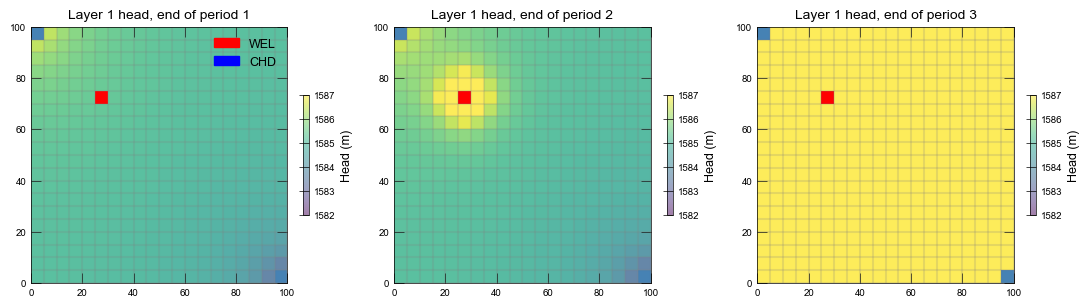

In [93]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

with flopy.plot.styles.USGSPlot():
    fig, axes = plt.subplots(1, 3, figsize=(11, 5))
    for i, (ax, arr, title) in enumerate([
        (axes[0], hds_kper0[1], "Layer 1 head, end of period 1"),
        (axes[1], hds_kper1[1], "Layer 1 head, end of period 2"),
        (axes[2], hds_kper2[1], "Layer 1 head, end of period 3"),
    ]):
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=10)
        if i == 0:
            ax.legend(
                handles=[
                    Patch(color="red", label="WEL"),
                    Patch(color="blue", label="CHD"),
                ],
            )
        mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=1)
        mm.plot_grid(alpha=0.2)
        pc = mm.plot_array(arr, alpha=0.5, vmin=1582, vmax=1587)
        plt.colorbar(pc, ax=ax, shrink=0.25, label="Head (m)")
        mm.plot_bc("WEL", plotAll=True, kper=1, color="red")
        mm.plot_bc("CHD", plotAll=True, color="steelblue")

    fig.tight_layout()
    plt.show()

Confirm that the top layer is dry by checking that its cells have head < 1590 m.

In [94]:
dry_layer0 = (hds_kper0[0] < bot[0]).sum()
print(f"Dry cells in top layer after first stress period: {dry_layer0} of {nrow * ncol}")

Dry cells in top layer after first stress period: 400 of 400


We can now begin setting up the particle tracking models. We will release particles
from the top-layer cell directly above the middle-layer injection well and its
immediately adjacent neighbors.

Release locations are defined with flopy's MP7 release-template module,
then converted with a flopy utility to a format suitable for PRT. This
demonstrates a key step in migrating an MP7 model to PRT.

In [95]:
offsets = [(-1, 0, 0), (-1, -1, 0), (-1, 1, 0), (-1, 0, -1), (-1, 0, 1)]
release_cells = [
    (wel_cellid[0] + dk, wel_cellid[1] + di, wel_cellid[2] + dj) for dk, di, dj in offsets
]
release_cells

[(0, 5, 5), (0, 4, 5), (0, 6, 5), (0, 5, 4), (0, 5, 6)]

Set up a cell template for MP7 template subdivision type 2.

In [96]:
mp7_cell_data = flopy.modpath.CellDataType(
    drape=1,
    rowcelldivisions=1,
    columncelldivisions=1,
    layercelldivisions=1
)

Set up a release region.

In [97]:
release_cells_T = np.array(release_cells).T
lrcregions = [[[
    min(release_cells_T[0]),
    min(release_cells_T[1]),
    min(release_cells_T[2]),
    max(release_cells_T[0]),
    max(release_cells_T[1]),
    max(release_cells_T[2])
]]]
lrcregions

[[[np.int64(0),
   np.int64(4),
   np.int64(4),
   np.int64(0),
   np.int64(6),
   np.int64(6)]]]

Now construct the MP7 model.

In [98]:
mp7_particle_data = flopy.modpath.LRCParticleData(
    subdivisiondata=mp7_cell_data,
    lrcregions=lrcregions,
)
mp7_pg = flopy.modpath.ParticleGroupLRCTemplate(
    particlegroupname="PG1",
    particledata=mp7_particle_data,
    filename="pg1.sloc",
)

mp7_name = f"{example_name}-mp7"
mp7_ws = base_ws / "mp7"
mp7_ws.mkdir(exist_ok=True, parents=True)

mp7 = flopy.modpath.Modpath7(
    modelname=mp7_name,
    flowmodel=gwf,
    exe_name="mp7",
    model_ws=mp7_ws,
    budgetfilename=f"{gwf_name}.cbb",
    headfilename=f"{gwf_name}.hds",
)

porosity = 0.1
bas = flopy.modpath.Modpath7Bas(
    mp7,
    porosity=porosity
)

mp7_sim = flopy.modpath.Modpath7Sim(
    mp7,
    simulationtype="pathline",
    budgetoutputoption="summary",
    particlegroups=[mp7_pg],
)

Write and run the MP7 simulation.

In [99]:
mp7.write_input()
mp7.run_model(silent=False)

FloPy is using the following executable to run the model: ../../../../../.pixi/envs/default/bin/mp7

MODPATH Version 7.2.001   
Program compiled May 26 2026 17:12:29 with GFORTRAN compiler (ver. 12.5.0)      


Run particle tracking simulation ...
Processing Time Step     1 Period     1.  Time =  1.00000E+00  Steady-state flow                                                    
Processing Time Step     1 Period     2.  Time =  2.82377E+00  Transient flow                                                       
Processing Time Step     2 Period     2.  Time =  4.82993E+00  Transient flow                                                       
Processing Time Step     3 Period     2.  Time =  7.03669E+00  Transient flow                                                       
Processing Time Step     4 Period     2.  Time =  9.46414E+00  Transient flow                                                       
Processing Time Step     5 Period     2.  Time =  1.21343E+01  Transient flow          

(True, [])

Load and plot MP7 results.

In [100]:
import pandas as pd

plf_mp7 = flopy.utils.PathlineFile(mp7_ws / f"{mp7_name}.mppth")
pls_mp7 = pd.concat(
    [pd.DataFrame(pdata) for pdata in plf_mp7.get_alldata()]
)
pls_mp7[pls_mp7.time == 0]

,particleid,particlegroup,sequencenumber,particleidloc,time,x,y,z,k,node,xloc,yloc,zloc,stressperiod,timestep
0,0,0,0,0,0.0,22.5,77.5,1582.724976,0,484,0.5,0.5,0.5,1,1
0,1,0,1,1,0.0,27.5,77.5,1582.697754,0,485,0.5,0.5,0.5,1,1
0,2,0,2,2,0.0,32.5,77.5,1582.672607,0,486,0.5,0.5,0.5,1,1
0,3,0,3,3,0.0,22.5,72.5,1582.697754,0,504,0.5,0.5,0.5,1,1
0,4,0,4,4,0.0,27.5,72.5,1582.676025,0,505,0.5,0.5,0.5,1,1
0,5,0,5,5,0.0,32.5,72.5,1582.655151,0,506,0.5,0.5,0.5,1,1
0,6,0,6,6,0.0,22.5,67.5,1582.672607,0,524,0.5,0.5,0.5,1,1
0,7,0,7,7,0.0,27.5,67.5,1582.655151,0,525,0.5,0.5,0.5,1,1
0,8,0,8,8,0.0,32.5,67.5,1582.637817,0,526,0.5,0.5,0.5,1,1


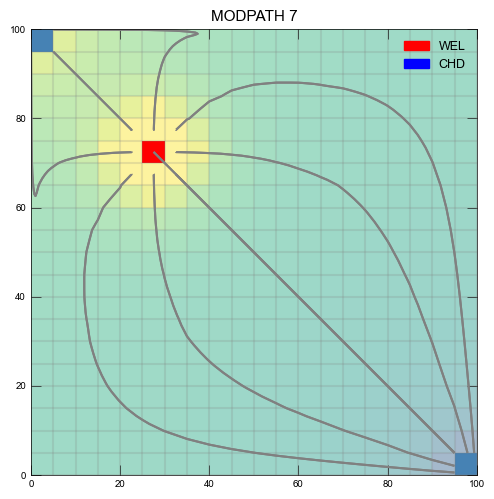

In [101]:
with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.set_aspect("equal")
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=1)
    mm.plot_grid(alpha=0.2)
    mm.plot_array(hds_kper1[1], alpha=0.25, vmin=1582, vmax=1587)
    mm.plot_bc("WEL", plotAll=True, kper=1, color="red")
    mm.plot_bc("CHD", plotAll=True, color="steelblue")
    mm.plot_pathline(pls_mp7)
    ax.set_title("MODPATH 7", fontsize=11)
    ax.legend(
        handles=[
            Patch(color="red", label="WEL"),
            Patch(color="blue", label="CHD"),
        ],
    )
    fig.tight_layout()
    plt.show()

Now construct an equivalent PRT model. Start by creating the simulation, time and grid discretization to match the flow model above, and a Model Input Package.

In [102]:
prt_name = f"{example_name}-prt"
prt_ws = base_ws / "prt"
prt_ws.mkdir(exist_ok=True, parents=True)

prt_sim = flopy.mf6.MFSimulation(
    sim_name=prt_name,
    exe_name="mf6",
    version="mf6",
    continue_=True,
    sim_ws=prt_ws,
)

tdis = flopy.mf6.ModflowTdis(
    prt_sim,
    time_units="days",
    nper=nper,
    perioddata=tdis_pd,
)

prt = flopy.mf6.ModflowPrt(
    prt_sim,
    modelname=prt_name,
    model_nam_file=f"{prt_name}.nam",
)

dis = flopy.mf6.ModflowPrtdis(
    prt,
    length_units=length_unit,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=bot,
)

mip = flopy.mf6.ModflowPrtmip(prt, porosity=porosity)

Convert MP7 particle release locations to PRP format.

In [103]:
release_pts = list(mp7_particle_data.to_prp(gwf.modelgrid))
prp = flopy.mf6.ModflowPrtprp(
    prt,
    nreleasepts=len(release_pts),
    packagedata=release_pts,
    nreleasetimes=1,
    releasetimes=[(0.0,)],
    print_input=True,
    drape=True,
)

In [104]:
oc = flopy.mf6.ModflowPrtoc(
    prt,
    budget_filerecord=[f"{prt_name}.bud"],
    track_filerecord=[f"{prt_name}.trk"],
    trackcsv_filerecord=[f"{prt_name}.csv"],
    saverecord=[("BUDGET", "ALL")],
    ntracktimes=1,
    tracktimes=[(100.0,)],
)

In [105]:
import os

rel_gwf_ws = os.path.relpath(gwf_ws, prt_ws)
fmi = flopy.mf6.ModflowPrtfmi(
    prt,
    packagedata=[
        ("GWFHEAD", f"{rel_gwf_ws}/{gwf_name}.hds"),
        ("GWFBUDGET", f"{rel_gwf_ws}/{gwf_name}.cbb"),
    ],
)

In [106]:
ems = flopy.mf6.ModflowEms(prt_sim, pname="ems", filename=f"{prt_name}.ems")

Write and run the PRT model.

In [107]:
prt_sim.write_simulation(silent=True)
prt_sim.run_simulation(silent=False)

FloPy is using the following executable to run the model: ../../../../../.pixi/envs/default/bin/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                       VERSION 6.8.0.dev0+afa8cfb3.dirty
                               ***DEVELOP MODE***

        MODFLOW 6 compiled May 21 2026 03:20:38 with GCC version 13.4.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the authorized or unauthorized 
use of the so

(True, [])

Load and plot PRT's results side by side with MP7's.

In [108]:
pls_prt = pd.read_csv(prt_ws / f"{prt_name}.csv")
pls_prt[pls_prt.ireason == 6]

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
1,1,1,1,1,1,2,485,0,1,6,0.0,0.0,22.5,77.5,1585.450030,NaN
4,1,1,1,1,2,2,486,0,1,6,0.0,0.0,27.5,77.5,1585.395386,NaN
7,1,1,1,1,3,2,487,0,1,6,0.0,0.0,32.5,77.5,1585.345285,NaN
10,1,1,1,1,4,2,505,0,1,6,0.0,0.0,22.5,72.5,1585.395386,NaN
13,1,1,1,1,5,2,506,0,1,6,0.0,0.0,27.5,72.5,1585.352047,NaN
16,1,1,1,1,6,2,507,0,1,6,0.0,0.0,32.5,72.5,1585.310417,NaN
19,1,1,1,1,7,2,525,0,1,6,0.0,0.0,22.5,67.5,1585.345285,NaN
22,1,1,1,1,8,2,526,0,1,6,0.0,0.0,27.5,67.5,1585.310417,NaN
25,1,1,1,1,9,2,527,0,1,6,0.0,0.0,32.5,67.5,1585.275534,NaN


In [109]:
pls_mp7[pls_mp7.time == 0]

,particleid,particlegroup,sequencenumber,particleidloc,time,x,y,z,k,node,xloc,yloc,zloc,stressperiod,timestep
0,0,0,0,0,0.0,22.5,77.5,1582.724976,0,484,0.5,0.5,0.5,1,1
0,1,0,1,1,0.0,27.5,77.5,1582.697754,0,485,0.5,0.5,0.5,1,1
0,2,0,2,2,0.0,32.5,77.5,1582.672607,0,486,0.5,0.5,0.5,1,1
0,3,0,3,3,0.0,22.5,72.5,1582.697754,0,504,0.5,0.5,0.5,1,1
0,4,0,4,4,0.0,27.5,72.5,1582.676025,0,505,0.5,0.5,0.5,1,1
0,5,0,5,5,0.0,32.5,72.5,1582.655151,0,506,0.5,0.5,0.5,1,1
0,6,0,6,6,0.0,22.5,67.5,1582.672607,0,524,0.5,0.5,0.5,1,1
0,7,0,7,7,0.0,27.5,67.5,1582.655151,0,525,0.5,0.5,0.5,1,1
0,8,0,8,8,0.0,32.5,67.5,1582.637817,0,526,0.5,0.5,0.5,1,1


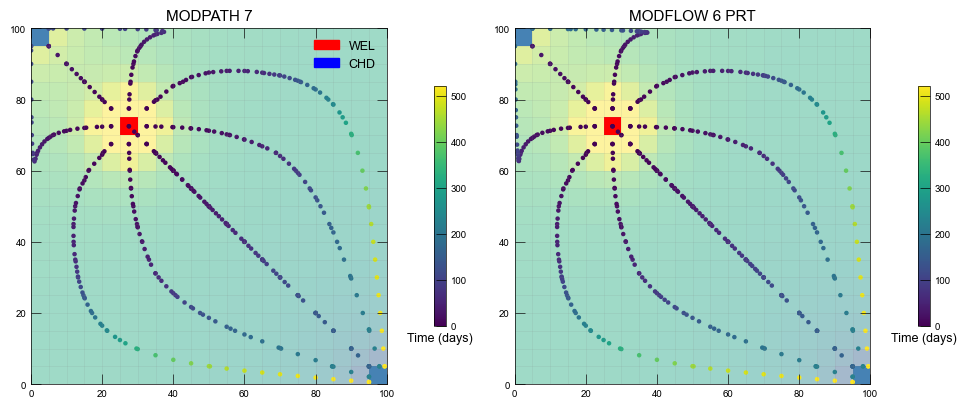

In [110]:
with flopy.plot.styles.USGSPlot():
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # mp7
    ax = axes[0]
    ax.set_aspect("equal")
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=0)
    mm.plot_grid(alpha=0.2, lw=0.4)
    mm.plot_array(hds_kper1[1], alpha=0.25, vmin=1582, vmax=1587)
    mm.plot_bc("WEL", plotAll=True, kper=1, color="red")
    mm.plot_bc("CHD", plotAll=True, color="steelblue")
    pc = ax.scatter(pls_mp7.x, pls_mp7.y, c=pls_mp7.time, s=5)
    cb = plt.colorbar(pc, shrink=0.5, pad=0.1)
    cb.ax.set_xlabel(r"Time (days)")
    ax.set_title("MODPATH 7", fontsize=11)

    # prt
    ax = axes[1]
    ax.set_aspect("equal")
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=0)
    mm.plot_grid(alpha=0.2, lw=0.4)
    mm.plot_array(hds_kper1[1], alpha=0.25, vmin=1582, vmax=1587)
    mm.plot_bc("WEL", plotAll=True, kper=1, color="red")
    mm.plot_bc("CHD", plotAll=True, color="steelblue")
    pc = ax.scatter(pls_prt.x, pls_prt.y, c=pls_prt.t, s=5)
    cb = plt.colorbar(pc, shrink=0.5, pad=0.1)
    cb.ax.set_xlabel(r"Time (days)")
    ax.set_title("MODFLOW 6 PRT", fontsize=11)

    axes[0].legend(
        handles=[
            Patch(color="red", label="WEL"),
            Patch(color="blue", label="CHD"),
        ],
    )

    fig.tight_layout()
    plt.show()

Let's plot pathlines in 3D now.

/var/folders/r9/yy7jb_8x0_s7zdkp6flb42980000gp/T/ipykernel_22739/1216841927.py:73: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  p.show()
2026-06-03 09:08:15.746 ( 837.619s) [          1010EB]vtkOpenGLRenderWindow.c:876   WARN| vtkCocoaRenderWindow (0x16c792bd0): Failed to get red color buffer size (1280)
2026-06-03 09:08:15.746 ( 837.619s) [          1010EB]vtkOpenGLRenderWindow.c:886   WARN| vtkCocoaRenderWindow (0x16c792bd0): Failed to get green color buffer size (1280)
2026-06-03 09:08:15.746 ( 837.619s) [          1010EB]vtkOpenGLRenderWindow.c:896   WARN| vtkCocoaRenderWindow (0x16c792bd0): Failed to get blue color buffer size (1280)
2026-06-03 09:08:15.746 ( 837.619s) [          1010EB]vtkOpenGLRenderWindow.c:906   WARN| vtkCocoaRenderWindow (0x16c792bd0): Failed to get alpha color buffer size (1280)


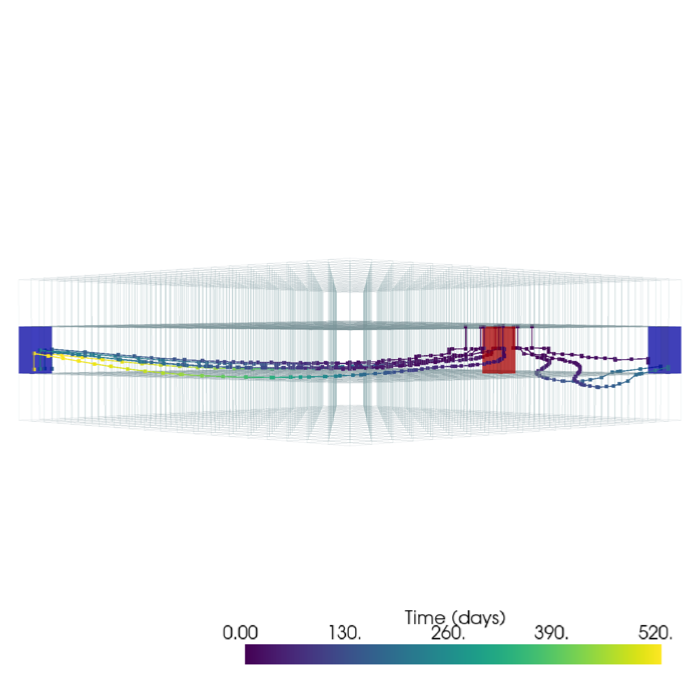

In [111]:
import pyvista as pv
from flopy.export.vtk import Vtk

def get_nn(i, j):
    """Convert a structured grid 2D cell index to a node number."""
    return i * ncol + j

# create mesh for WEL boundary condition
wel_nn = get_nn(*wel_cellid[1:])
wel_pts = gwf.modelgrid.verts[gwf.modelgrid.iverts[wel_nn]]
wel_xs, wel_ys = list(zip(*wel_pts))
wel_mesh = pv.Box(
    bounds=[
        min(wel_xs),
        max(wel_xs),
        min(wel_ys),
        max(wel_ys),
        bot[wel_cellid[0]].max(),
        bot[wel_cellid[0] - 1].max(),
    ]
)

# create mesh for CHD boundary condition
chd_nns = [get_nn(*chd0_cellid[1:]), get_nn(*chd1_cellid[1:])]
chd0_pts = gwf.modelgrid.verts[gwf.modelgrid.iverts[chd_nns[0]]]
chd1_pts = gwf.modelgrid.verts[gwf.modelgrid.iverts[chd_nns[1]]]
chd0_xs, chd0_ys = list(zip(*chd0_pts))
chd1_xs, chd1_ys = list(zip(*chd1_pts))
chd_mesh = pv.Box(
    bounds=[
        min(chd0_xs),
        max(chd0_xs),
        min(chd0_ys),
        max(chd0_ys),
        bot[chd0_cellid[0]].max(),
        bot[chd0_cellid[0] - 1].max(),
    ]
).merge(pv.Box(
    bounds=[
        min(chd1_xs),
        max(chd1_xs),
        min(chd1_ys),
        max(chd1_ys),
        bot[chd1_cellid[0]].max(),
        bot[chd1_cellid[0] - 1].max(),
    ]
))

# create meshes for model results
vtk = Vtk(model=gwf, binary=False)
vtk.add_model(gwf)
vtk.add_pathline_points(pls_prt.to_records(index=False))
# vtk.add_pathline_points(pls_mp7.to_records(index=False))
gwf_mesh, prt_mesh = vtk.to_pyvista()

# create plot
axes = pv.Axes(show_actor=False, actor_scale=2.0, line_width=5)
p = pv.Plotter(window_size=[700, 700])
p.enable_anti_aliasing()
p.add_mesh(gwf_mesh, opacity=0.1, style="wireframe")
p.add_mesh(wel_mesh, color="red", opacity=0.5)
p.add_mesh(chd_mesh, color="blue", opacity=0.5)
p.add_mesh(
    prt_mesh,
    point_size=8,
    line_width=2.5,
    smooth_shading=True,
    color="blue",
    scalars="t",
    scalar_bar_args={"title": "Time (days)"},
)
p.camera.elevation -= 35
p.show()

The particles haven't moved!

Without Newton, top-layer cells are deactivated when they drain below their
bottoms. By default, particles starting at `t=0` in the top layer terminate
immediately, since at `t=0` (end of 1st stress period) the top layer is dry.

We can now turn on the DRAPE option for both MP7 and PRT, and observe that
particles drop to the water table immediately, and are tracked from there.

Next, we can turn DRAPE off, enable the Newton formulation, and compare the
behavior of PRT and MP7. 

### Release time behavior

```mermaid
flowchart LR
    ACTIVE --> |No| DRAPE(DRAPE)
    ACTIVE{Cell active?} --> |Yes| RELEASE[Release in specified cell]:::release
    DRAPE ==> |No| TERMINATE:::terminate
    DRAPE ==> |Yes| ACTIVE_UNDER{Active under?}
    ACTIVE_UNDER --> |Yes| RELEASE_AT_TABLE[Drape to active cell]:::release
    ACTIVE_UNDER --> |No| TERMINATE[Terminate]

    classDef release stroke:#98fb98
    classDef terminate stroke:#f08080
```

### Tracking time behavior

```mermaid
flowchart LR
    ACTIVE{Cell active?} --> |No| TERMINATE{Terminate}
    ACTIVE{Cell active?} --> |Yes| PARTICLE_DRY
    PARTICLE_DRY{Particle dry?} --> |Yes| DRY_TRACKING_METHOD(DRY_TRACKING_METHOD)
    DRY_TRACKING_METHOD ==> |STOP| TERMINATE[Terminate]:::terminate
    DRY_TRACKING_METHOD ==> |DROP| CELL_DRY{Cell dry?}
    CELL_DRY --> |Yes| DROP_BOTTOM[Pass to cell bottom]:::track
    CELL_DRY --> |No| DROP_TABLE([Pass to water table])
    DRY_TRACKING_METHOD ==> |STAY| STAY[Stationary]:::track
    DROP_TABLE --> TRACK:::track
    PARTICLE_DRY --> |No| TRACK[Track normally]

    classDef track stroke:#98fb98
    classDef terminate stroke:#f08080
```